In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

In [5]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")
df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6.0,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6.0,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32.0,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [6]:
#data cleaning
df.describe() #summary of data characteristics so we can see scale of numerics
#quantity has neg values so in invoice orders were returned

,Quantity,UnitPrice,CustomerID
count,529607.000000,529607.000000,398829.000000
mean,9.556601,4.623402,15286.079952
std,154.449903,97.746839,1713.072189
min,-74215.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13952.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16790.000000
max,74215.000000,38970.000000,18287.000000


In [7]:
df.isna().sum() #checks for missing values and tells us how many if any

InvoiceNo           0
StockCode           0
Description      1446
Quantity            1
InvoiceDate         1
UnitPrice           1
CustomerID     130779
Country             1
dtype: int64

In [8]:
# drop rows with no CustomerID — we cant do customer analysis without it
 # subset only drops rows where CustomerID is missing so we drop 135080 rows to maintain the other 400000+ in the column
df = df.dropna(subset=['CustomerID'])

# remove cancelled orders — invoices starting with C are cancellations not purchases ypu see this around row 4000+
df = df[df['InvoiceNo'].astype(str).str.contains('C') == False] #keeps only rows taht do not start with c

# remove negative or zero quantities cause its canceled orders we missed
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# convert date column to datetime so we can do date math later
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True) # to_datetime jst lets pandas know its a date so we can fidn the max date and such earlier and subtract dates too

# create TotalPrice — quantity times unit price gives us revenue per row
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df.shape)
df.head()

(390087, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


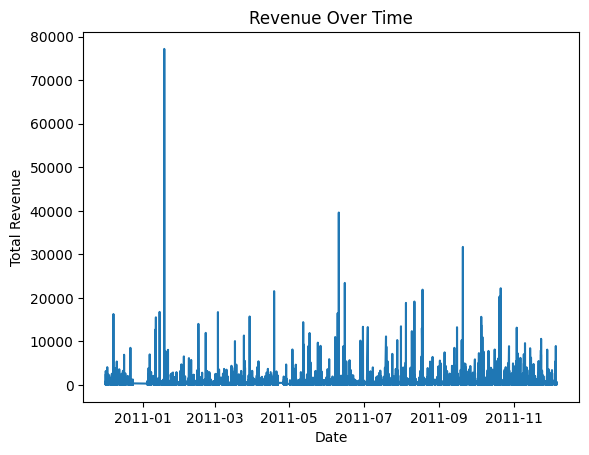

In [ ]:
# Explanatory Data Analysis 
#revenue change over time 
revenue = df.groupby('InvoiceDate')['TotalPrice'].sum() 
# groups all rows by date then adds up the total price for each date

plt.plot(revenue)
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

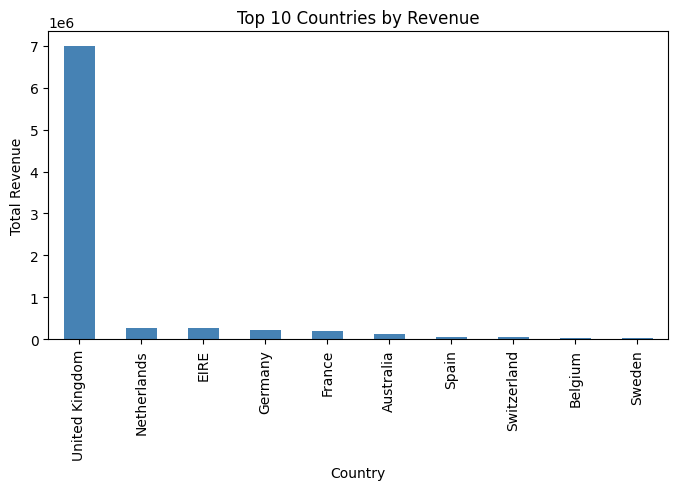

In [11]:
# top 10 countries by revenue
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.show()